In [ ]:
import pickle
import pickle
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


In [2]:
with open('../../data/trueans_10regular.pkl', 'rb') as f:
    dict_true_10regular = pickle.load(f)

with open('../../data/trueans.pkl', 'rb') as f:
    dict_true = pickle.load(f)



In [ ]:
se = 42
temp = 2.0
cl = 100
size = 10


In [ ]:
accs_ft = {}

degree = 3
with open(f'../evaluation/outputs/finetuned_gqcoans_s{se}_t{temp}_cl{int(cl)}_s{size}_degree{degree}.pkl', 'rb') as f:
    dct = pickle.load(f)
print(sum(dct["answer"]))
accs_ft[degree] = sum(dct["answer"])/len(dct["answer"])


979


In [10]:
accs = {}
for degree in range(3,10):
    with open(f'../evaluation/outputs/gqcoans_s{se}_t{temp}_cl{int(cl)}_s{size}_degree{degree}.pkl', 'rb') as f:
        dct = pickle.load(f)
    print(sum(dct["answer"]))
    accs[degree] = sum(dct["answer"])/len(dct["answer"])

accs[9] = 0.981


950
972
981
976
978
991
987


/tmp/ipykernel_3138104/1846819528.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


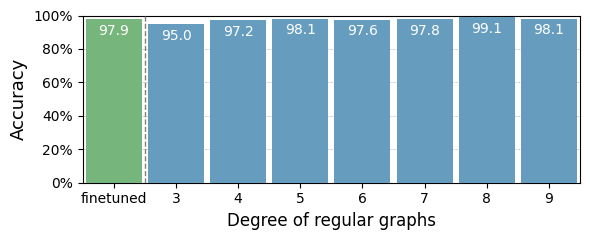

In [ ]:
palette = {
    'Brute-force': sns.color_palette('Blues', 24)[10],
    'SA': sns.color_palette('Blues', 24)[14],
    'QAOA': sns.color_palette('Blues', 24)[10],
    'GQCO': sns.color_palette('Blues', 24)[13],
    'Random': sns.color_palette("Blues", 24)[1],
    'finetuned': sns.color_palette("Greens", 24)[12],
}

accs['finetuned'] = 0.979
new_order = ['finetuned'] + [k for k in accs.keys() if k != 'finetuned']
accs_ordered = {k: accs[k] for k in new_order}

new_df = pd.DataFrame({
    'Degree': list(accs_ordered.keys()),
    'Accuracy': list(accs_ordered.values()),
    'Color': [palette['GQCO'] if k != 'finetuned' else palette['finetuned'] for k in accs_ordered.keys()]
})

plt.figure(figsize=(6, 2.5))
ax = sns.barplot(
    data=new_df,
    y='Accuracy',
    x='Degree',
    palette=new_df['Color'].tolist(),
    zorder=10,
    width=0.9
)

plt.axvline(x=0.5, color='gray', linestyle='--', linewidth=1, zorder=9)

plt.grid(axis='y', which='both', color='gray', alpha=0.5, linestyle='--', linewidth=0.5, zorder=2)
plt.xlabel('Degree of regular graphs', size=12)
plt.ylabel('Accuracy', size=13)
plt.ylim([0, 1])
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y * 100:.0f}%'))

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f'{p.get_height() * 100:.1f}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='center',
            fontsize=10,
            color='white',
            xytext=(0, -8.5),
            textcoords='offset points',
            zorder=11,
            rotation=0
        )

plt.tight_layout()
plt.savefig('./810_acc10regular_finetuned.svg')
